# Predicción de popularidad de canciones en Spotify

**Autor:** Gino Andrades,
           Verónica Cereceda

**Fecha de Creación:** Septiembre de 2026

**Versión:** 1.0

## Descripción

Desarrollo de un análisis exploratorio de datos (EDA) y diagnóstico de calidad sobre el dataset de canciones de Spotify, aplicando las etapas iniciales de la metodología CRISP-DM, con el fin de identificar los patrones, calidad y variables relevantes que describen la popularidad musical.

## Información general

Realizar un análisis exploratorio de los datos, incluyendo preparación, transformación y diagnóstico de calidad, aplicando la metodología CRISP-DM, con el fin de identificar patrones, calidad de los datos y variables relevantes asociadas al nivel de popularidad de las canciones.

## **1. Configuración del Entorno**

Se prepara el entorno de trabajo,se descarga el dataset desde el repositorio de GitHub del proyecto, se importan las librerías necesarias para el análisis y se carga el archivo CSV en un Data para su exploración.

### *1.1 Descarga del Dataset*

In [1]:
!wget https://raw.githubusercontent.com/VeritoCR/Repositorio_Spotify_Tracks/refs/heads/main/data/Spotify_Tracks_Dataset.csv

--2026-09-03 20:45:45--  https://raw.githubusercontent.com/VeritoCR/Repositorio_Spotify_Tracks/refs/heads/main/data/Spotify_Tracks_Dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20118244 (19M) [text/plain]
Saving to: ‘Spotify_Tracks_Dataset.csv.1’

Spotify_Tracks_Data 100%[===================>]  19.19M  39.7MB/s    in 0.5s    

2026-09-03 20:45:49 (39.7 MB/s) - ‘Spotify_Tracks_Dataset.csv.1’ saved [20118244/20118244]



### *1.2 Importaciones necesarias para trabajar.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

### *1.3 Cargar los registros a la variable "data" con pandas*

Se carga el dataset **Spotify_Tracks_Dataset.csv** directamente desde el repositorio de GitHub del proyecto, y se realiza una primera inspección general para conocer su tamaño, tipos de datos y estructura antes de iniciar el diagnóstico de calidad.

In [3]:
data=pd.read_csv('Spotify_Tracks_Dataset.csv')

## **2. Exploración Inicial y Perfilamiento**

Se realiza un análisis exploratorio completo del dataset, revisando su estructura, calidad de datos, distribución de variables y las relaciones entre variables,con foco en identificar qué factores se asocian con la variable objetivo. Esta etapa permite detectar problemas de calidad que deberán tratarse en la preparación de datos, así como hallazgos relevantes sobre el comportamiento del catálogo musical.

### *2.1 Inspección Estructural del Dataset*


In [4]:
# Dimensiones del dataset
print(f"Filas: {data.shape[0]}, Columnas: {data.shape[1]}")

Filas: 114000, Columnas: 21


In [5]:
# Tipos de datos por columna
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

El dataset contiene 114.000 registros y 21 columnas. Se observan tres tipos de datos principales:
- **Variables categóricas**:track_id,artists,album_name, track_name,track_genre.
- **Variables numéricas**:popularity,duration_ms,danceability,energy, loudness, tempo,entre otras.
- **Variable booleana**:explicit.

Además, se identifica la columna **Unnamed:0**,que corresponde a un índice residual sin valor analítico.

### *2.2 Visualización Preliminar de Registros*

In [6]:
# Desplegamos las primeras 5 filas del dataset para una validación visual.
data.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


**Observacion:** El análisis visual de los primeros cinco registros confirma que la estructura relacional del dataset se cargó de acuerdo con los parámetros esperados. Esta vista preliminar resulta clave para auditar el comportamiento inicial de las celdas y analizar la naturaleza de las variables.

### *2.3 Análisis Estadístico Descriptivo*

In [7]:
display(data.drop(columns=['Unnamed: 0']).describe())

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


**Observaciones:**
* Posible valor nulo: duration_ms tiene un mínimo de 0.000 ms. No existen pistas de audio con duración cero, por lo que se trata de registros corruptos que deben filtrarse en la etapa de limpieza.

* Duration_ms: La mediana de duración es de 213 segundos (3,5 minutos),con un promedio de 3,8 minutos. Sin embargo, el máximo llega a 5.237 segundos (87 minutos), lo que indica audiolibros, grabaciones continuas o podcasts.

**Distribuciones y Sesgos Notables**
* popularity:La media es de apenas 33.24 y la mediana 35.0, con un percentil 75 en 50.La gran mayoría de los tracks tiene baja popularidad, concentrándose el éxito masivo (>75-100) en una minoría pequeña del catálogo.

* instrumentalness:El percentil 50 es de solo 0.000042 y el percentil 75 es 0.049.Más del 75% del dataset corresponde a canciones con voz predominante, solo una fracción pequeña supera el umbral comúnmente aceptado (>0.5) para pistas instrumentales puras.

* speechiness:El percentil 75 se sitúa en 0.0845 (8.4%).Menos del 10% del catálogo corresponde a géneros intensivos en texto hablado (como podcasts, audiolibros o rap muy denso).

* liveness:Con una mediana de 0.13 y percentil 75 de 0.27, la inmensa mayoría son canciones de estudio.

### *2.4 Detección de Registros Duplicados*

In [8]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(0)

### *2.5 Detección de Valores Atípicos (Outliers)*

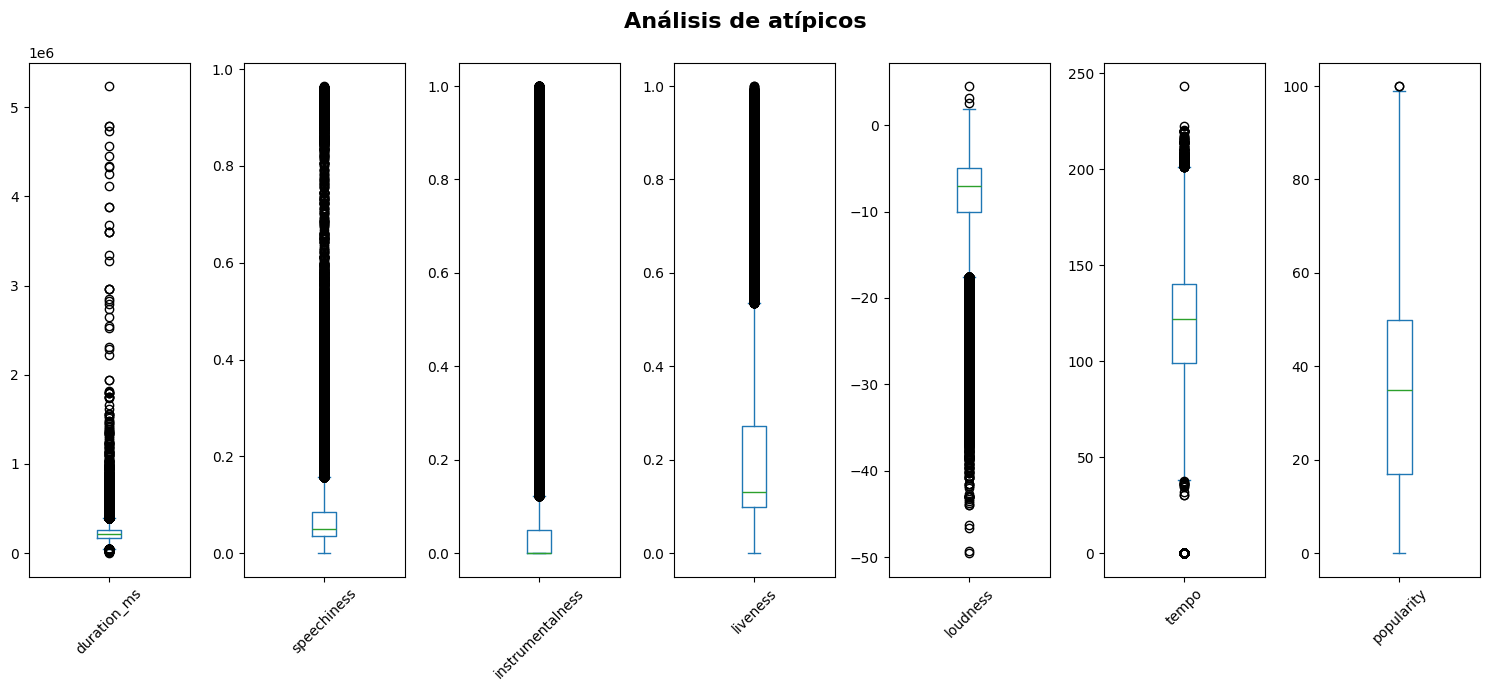

In [9]:
revision_atipicos = ['duration_ms', 'speechiness', 'instrumentalness',	'liveness', 'loudness', 'tempo', 'popularity']
fig, axes = plt.subplots(1, 7 , figsize=(20,20))
axes = axes.flatten()
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(15,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

**duration_ms (Duración en ms):**
Evidencia una distribución con asimetría positiva severa. Refleja la coexistencia de pistas estándar con audiolibros, podcasts o grabaciones continuas, además de posibles registros con duración 0 ms en la base.

**speechiness, instrumentalness y liveness (Variables con lineas negras de atípicos):** No se trata de fallos de medición, sino del reflejo de que el catálogo comercial típico está compuesto por música cantada de estudio. Las canciones instrumentales puras (>0.2), pistas habladas/rap denso (>0.2) o conciertos en vivo (>0.5) son una minoría natural, pero matemáticamente el criterio IQR los marca masivamente como outliers.

**loudness (Sonoridad en dB):** Pistas extremadamente silenciosas (efectos de sonido, pistas ambientales o silencios al inicio de grabaciones) jalan la cola izquierda. Los atípicos superiores indican posible compresión agresiva de rango dinámico.

**tempo (BPM):Comportamiento:** Los atípicos son puntuales: valores cercanos a 0 BPM (errores de detección de ritmo o silencios) y pistas muy aceleradas ($>200$ BPM, como géneros electrónicos intensos tipo Drum & Bass o Speedcore).

**popularity (Popularidad):** Prácticamente carece de outliers, salvo un par de puntos aislados en el valor máximo (100). Indica que el catálogo cubre todo el espectro de reproducciones de forma continua.

In [10]:
print(f"Registros con duration_ms = 0: {(data['duration_ms']==0).sum()}")
print(f"Popularidad de ese registro: {data[data['duration_ms']==0]['popularity'].values}")

print(f"\nRegistros con duración mayor a 15 minutos: {(data['duration_ms'] > 900000).sum()}")
data.nlargest(10, 'duration_ms')[['track_name', 'artists', 'duration_ms']]

Registros con duration_ms = 0: 1
Popularidad de ese registro: [0]

Registros con duración mayor a 15 minutos: 153


,track_name,artists,duration_ms
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,5237295
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,4789026
10984,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,4789026
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,4730302
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,4563897
13344,House of Om - Mark Farina - Continuous Mix,Mark Farina,4447520
13245,Live In Tokyo - Continuous Mix,Mark Farina,4339826
13195,Greenhouse Construction,Mark Farina,4334721
27926,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",Lenzman;Dan Stezo,4246206
101390,Ocean Waves Sounds,Ocean Sounds,4120258


Solo hay 1 canción con duración 0, y resulta que esa misma tiene popularidad 0.Tiene sentido,si el dato de duración está roto, es lógico que tampoco tenga reproducciones ni popularidad registrada.
Por otro lado, hay 153 canciones que superan los 15 minutos. Pero al mirar los nombres, no son canciones normales,son mezclas continuas de DJ ("Continuous DJ Mix"), sets en vivo o sonidos ambientales como "Ocean Waves Sounds". No es un error de los datos, es que el dataset mezcla distintos tipos de contenido bajo la misma categoría de "canción".

### *2.6 Identificación de Datos Faltantes y Negativos*

#### *2.6.1 Conteo de nulos en variables cuantitativas*

In [11]:
#Calculamos los nulos en las columnas
nulos = data.select_dtypes(include=['float64', 'int64']).isnull().sum()

#Construimos el DataFrame directamente
df_nulos_cuant = pd.DataFrame({
    'Cantidad_Nulos': nulos,
    'Porcentaje_Nulos': round(nulos / len(data) * 100, 2)
})
#Filtramos las columnas con nulos, ordenamos y desplegamos
resultado = df_nulos_cuant[df_nulos_cuant['Cantidad_Nulos'] > 0].sort_values(by='Porcentaje_Nulos', ascending=False)

if resultado.empty:
    print("No se detectaron valores nulos en ninguna columna numérica del dataset.")
else:
    display(resultado)

No se detectaron valores nulos en ninguna columna numérica del dataset.


#### *2.6.2 Conteo de negativos en variables cuantitativas*

In [12]:
# 1. Calculamos los valores negativos (< 0) en las columnas numéricas
negativos = data.select_dtypes(include=['float64']).lt(0).sum()

# 2. Construimos el DataFrame directamente
df_negativos_cuant = pd.DataFrame({
    'Cantidad_Negativos': negativos,
    'Porcentaje_Negativos': round(negativos / len(data) * 100, 2)
})

# 3. Filtramos las columnas que tengan negativos, ordenamos y desplegamos
display(df_negativos_cuant[df_negativos_cuant['Cantidad_Negativos'] > 0].sort_values(by='Cantidad_Negativos', ascending=False))

,Cantidad_Negativos,Porcentaje_Negativos
loudness,113910,99.92


### *2.7 Perfilamiento y Consistencia de Atributos Cualitativos*

#### *2.7.1 Análisis Descriptivo de Campos Categorizados*

In [13]:
# Nos muestra todas las variables que son tipo object, nos ayudara a indentificar las variables cualitativas
data.drop(columns=['track_id']).describe(include="object")

,artists,album_name,track_name,track_genre
count,113999,113999,113999,114000
unique,31437,46589,73608,114
top,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,279,195,151,1000


#### *2.7.2 Conteo de nulos en variables cualitativas*

In [14]:
# 1. Calculamos los nulos en las columnas
nulos = data.select_dtypes(include=['object']).isnull().sum()

# 2. Construimos el DataFrame directamente
df_nulos_cuant = pd.DataFrame({
    'Cantidad_Nulos': nulos,
    'Porcentaje_Nulos': round(nulos / len(data) * 100, 2)
})

# 3. Filtramos las columnas con nulos, ordenamos y desplegamos
display(df_nulos_cuant[df_nulos_cuant['Cantidad_Nulos'] > 0].sort_values(by='Porcentaje_Nulos', ascending=False))

,Cantidad_Nulos,Porcentaje_Nulos
artists,1,0.0
album_name,1,0.0
track_name,1,0.0


#### *2.7.3 Exploración de Dominios y Cardinalidad Categórica*

In [15]:
# Seleccionamos automáticamente las columnas de tipo 'object' (categóricas).
variables_cualitativas = data.drop(columns=['track_id', 'track_name', 'artists', 'album_name']).select_dtypes(include=['object']).columns

# Iteramos para inspeccionar la integridad y los valores posibles de cada atributo.
for col in variables_cualitativas:
    print("_" * 110) # Separador
    print(f"\n Valores de {col}: {data[col].unique()}")
print("_" * 110) # Separador

______________________________________________________________________________________________________________

 Valores de track_genre: ['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie-pop' 'indie' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop-film' 'pop' 'power-pop'
 'progressive-house' 'psych-ro

### *2.8 Análisis de Distribución y Sesgo de la Variable Objetivo*

Se analiza la distribución de la variable objetivo popularity, evaluando su forma, tendencia central y grado de asimetría, con el fin de comprender su comportamiento.

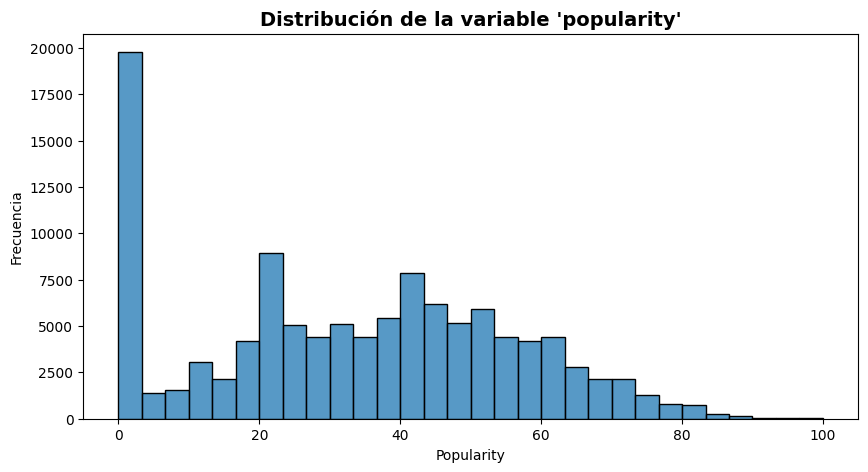

Sesgo de popularity: 0.046


In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(data['popularity'], bins=30)
plt.title("Distribución de la variable 'popularity'", fontsize=14, fontweight="bold")
plt.xlabel("Popularity")
plt.ylabel("Frecuencia")
plt.show()
print(f"Sesgo de popularity: {skew(data['popularity']):.3f}")

Lo primero que llama la atención es la barra en 0,casi 20.000 canciones tienen popularidad 0, muy por encima de cualquier otro valor. Después de ese pico hay una caída fuerte y recién desde el rango 15-20 en adelante la distribución empieza a tomar una forma más "normal", con la mayor concentración entre 20 y 55, y bajando de a poco hacia los valores altos (80-100).

Ese grupo de canciones con popularidad 0 probablemente corresponde a temas con muy pocas reproducciones o sin suficiente historial para que Spotify les asigne un puntaje mayor.
Lo siguiente es que el skewness dio casi 0 (0.046),lo que normalmente indicaría una distribución simétrica. Pero el gráfico muestra algo distinto, hay un salto grande en 0 que no se ve reflejado en ese número, porque el resto de la distribución compensa el cálculo. Esto muestra que fijarse solo en el valor de skewness puede llevar a una conclusión equivocada si no se revisa también el histograma.

### *2.9 Distribución de las Variables Numéricas*

Se analiza la distribución individual de las principales variables numéricas del dataset, con el fin de identificar su forma, posibles sesgos y rangos de concentración, complementando el análisis de outliers realizado previamente.

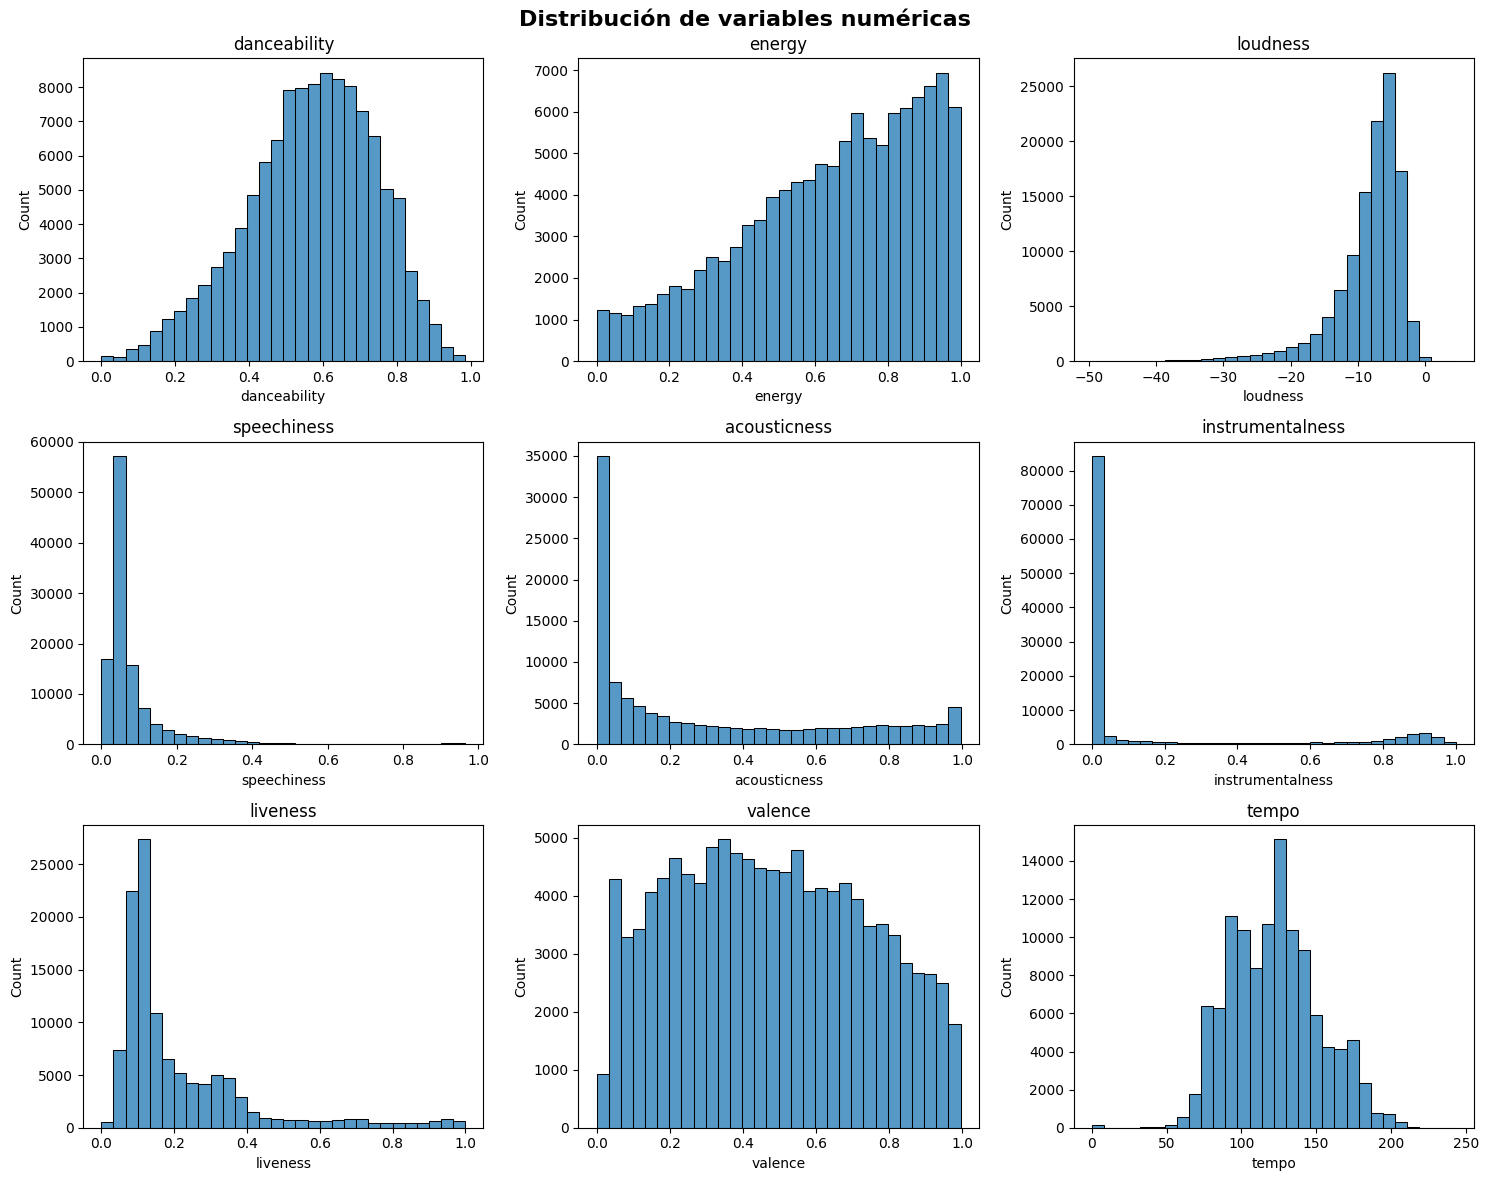

In [17]:
variables_features = ['danceability', 'energy', 'loudness', 'speechiness',
                       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(variables_features):
    sns.histplot(data[col], bins=30, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle("Distribución de variables numéricas", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Varias de las variables de audio muestran distribuciones muy concentradas en valores bajos (speechiness, instrumentalness, liveness, acousticness),lo que significa que estas columnas aportan poca variabilidad para diferenciar canciones entre sí.

**loudness** está concentrada entre -10 y 0 dB, lo que confirma una práctica común de masterización moderna.La cola hacia valores muy negativos probablemente corresponde a grabaciones más antiguas o de menor calidad de producción, lo que podría ser un factor indirecto relacionado con la popularidad.

**danceability**,**valence** y **tempo** son las variables con distribución más "normal" y balanceada del grupo.

El caso de **acousticness** es particular,además de la concentración en 0, tiene un repunte visible cerca de 1.0. Esto sugiere que el data mezcla dos grupos bastante distintos de canciones, más que una transición gradual entre ambos extremos.

En conjunto, el hallazgo más útil de este análisis es que varias variables (speechiness, instrumentalness, liveness) están dominadas por un solo valor y podrían no ser buenos predictores individuales de popularidad, mientras que variables como loudness, danceability y valence, al tener mayor variabilidad, son candidatas más prometedoras para explorar su relación con **popularity**.

### *2.10 Análisis de Correlación y Multicolinealidad*
Se analiza la relación entre las variables numéricas mediante una matriz de correlación, con el fin de identificar qué variables se asocian más con popularity,y detectar posibles relaciones fuertes entre variables.

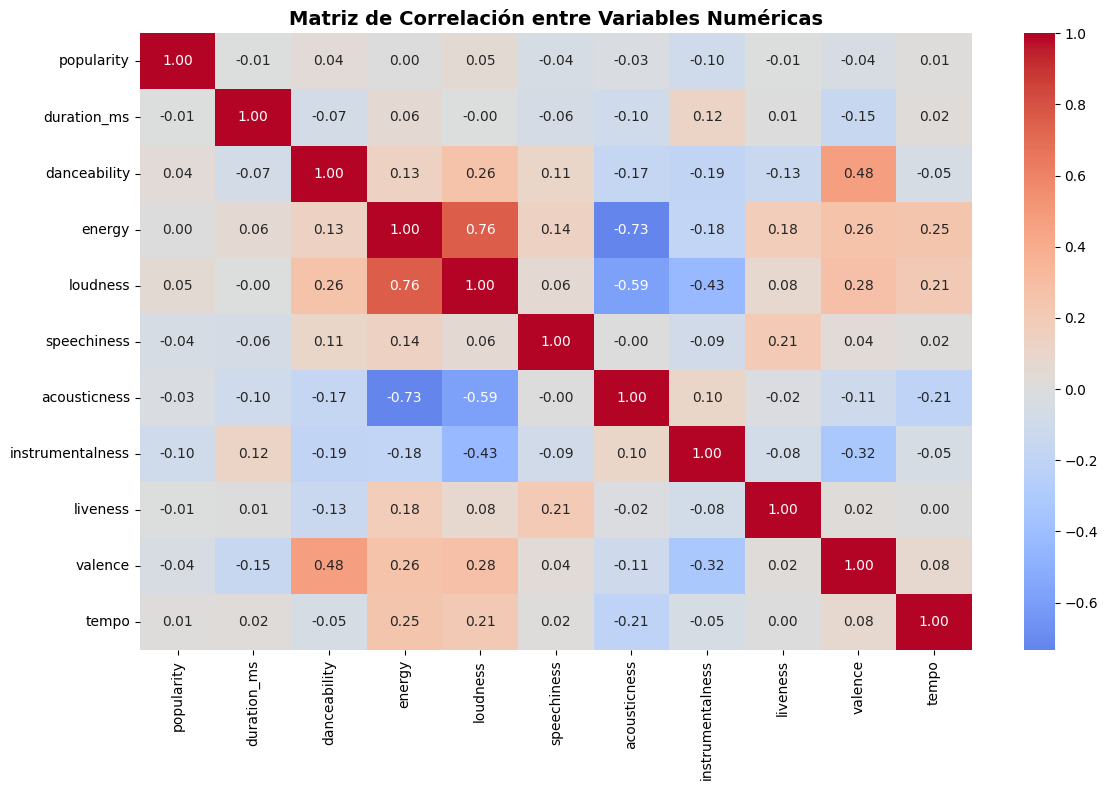

In [18]:
variables_numericas = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                        'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                        'valence', 'tempo']

matriz_corr = data[variables_numericas].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

El hallazgo más importante de esta matriz es que ninguna variable de audio tiene una correlación lineal relevante con popularity,todos los valores están entre -0.10 y 0.05, prácticamente cero. Esto significa que no existe una única característica de audio. que por sí sola explique por qué una canción es más o menos popular.La variable más cercana es instrumentalness, sugiriendo apenas una leve tendencia de que canciones instrumentales tienden a ser un poco menos populares, pero es una relación muy débil para sacar conclusiones.

Esto es relevante para el proyecto, porque la popularidad probablemente no se explica por atributos de audio de forma aislada, sino por una combinación de varios factores a la vez. Un modelo lineal simple basado en estas variables probablemente tendría un poder predictivo limitado.

### *2.11 Análisis de Correlación de Spearman*

La matriz de correlación de Pearson solo captura relaciones **lineales** entre variables. Para verificar si existen relaciones **no lineales** que no fueron detectadas anteriormente,especialmente con la variable objetivo popularity,se calcula adicionalmente la correlación de Spearman, la cual evalúa la relación entre los rangos de las variables en lugar de sus valores absolutos.

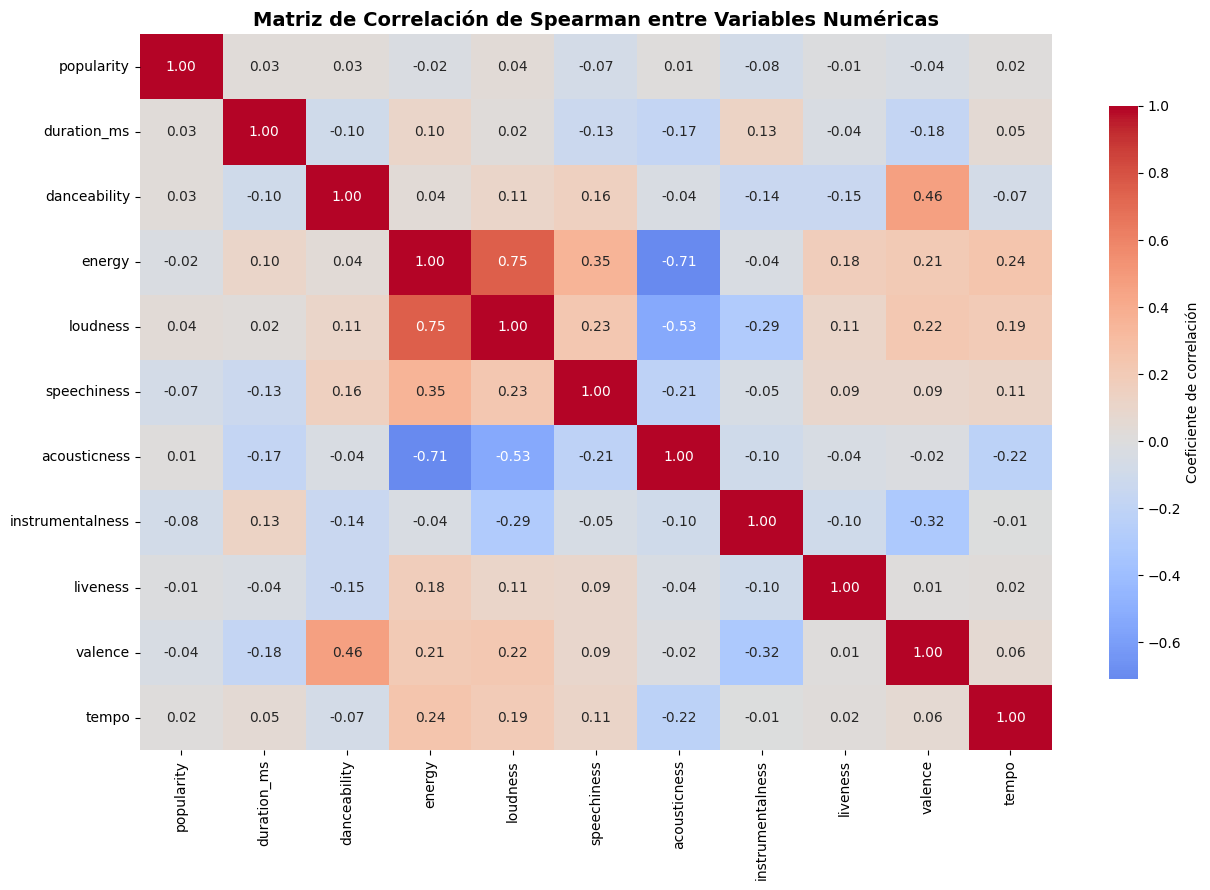

In [19]:
matriz_spearman = data[variables_numericas].corr(method='spearman')

plt.figure(figsize=(13, 9))
sns.heatmap(matriz_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlación'})
plt.title("Matriz de Correlación de Spearman entre Variables Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

La matriz de Spearman confirma lo observado con Pearson,tampoco existe una relación relevante entre popularity y las variables de audio. Los valores se mantienen igual de bajos entre -0.08 y 0.04, por lo que descartar relaciones lineales no estaba ocultando una relación no lineal más fuerte — simplemente no hay una asociación fuerte de ningún tipo entre estas variables individuales y la popularidad.


### *2.12 Relación entre popularity y Variables Categóricas*

Dado que las matrices de correlación de Pearson y Spearman no evidenciaron relaciones relevantes entre popularity y las variables de audio, se explora la relación de la variable objetivo con variables categóricas del dataset,el género musical **track_genre** y el carácter explícito de la canción **explicit**, con el fin de identificar si estos factores están más asociados al nivel de popularidad.

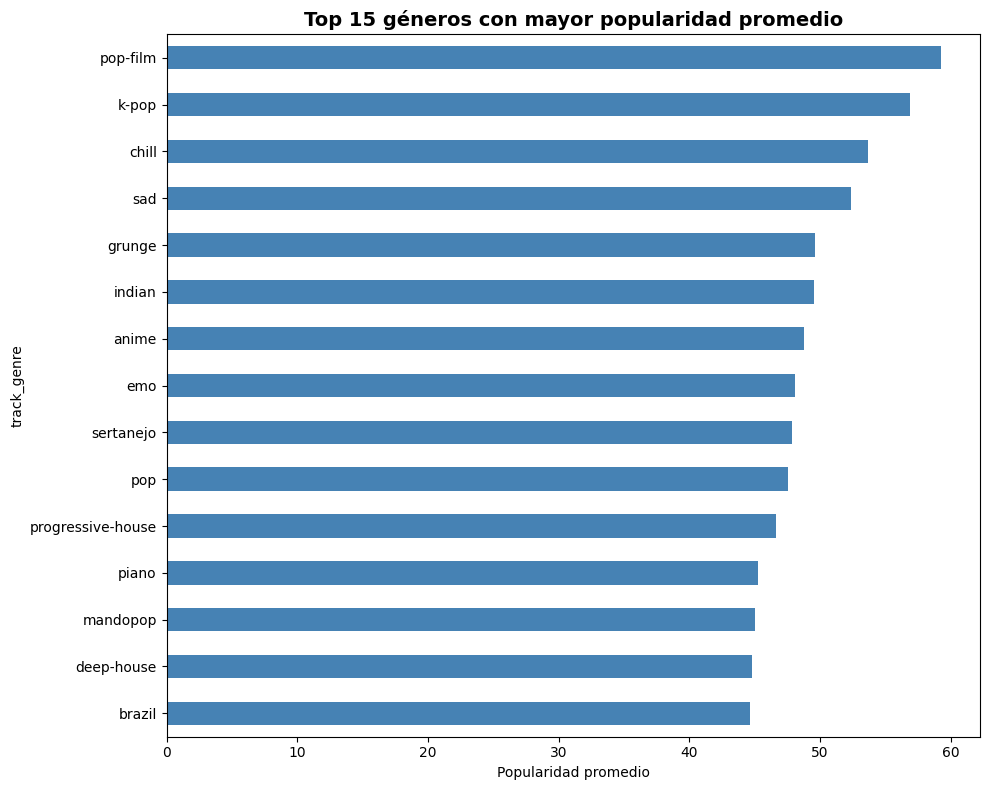

Top 5 géneros más populares:
track_genre
pop-film    59.283
k-pop       56.896
chill       53.651
sad         52.379
grunge      49.594
Name: popularity, dtype: float64

Top 5 géneros menos populares:
track_genre
chicago-house     12.339
detroit-techno    11.174
latin              8.297
romance            3.245
iranian            2.210
Name: popularity, dtype: float64


In [20]:
popularidad_genero = data.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
popularidad_genero.head(15).plot(kind='barh', color='steelblue')
plt.title("Top 15 géneros con mayor popularidad promedio", fontsize=14, fontweight="bold")
plt.xlabel("Popularidad promedio")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 géneros más populares:")
print(popularidad_genero.head())
print("\nTop 5 géneros menos populares:")
print(popularidad_genero.tail())

A diferencia de las variables de audio, el género musical sí muestra una relación clara con la popularidad. El género más popular en promedio es pop-film (59.3), seguido de k-pop (56.9), chill (53.7),sad (52.4) y grunge (49.6), géneros asociados a la música mainstream y a bandas sonoras de gran exposición mediática. En el otro extremo, géneros como iranian (2.2), romance (3.2) y latin`(8.3) presentan una popularidad promedio muy baja, lo que sugiere que corresponden a nichos con menor alcance dentro de la plataforma o menor representación en el dataset.


**Relación entre popularity y explicit**

In [21]:
data.groupby('explicit')['popularity'].mean()

explicit
False    32.937891
True     36.454191
Name: popularity, dtype: float64

Las canciones marcadas como explícitas tienen en promedio más popularidad (36.45) que las no explícitas (32.94). La diferencia es de casi 3.5 puntos, no es enorme pero es consistente. Puede relacionarse con géneros como el rap o el hip-hop, que suelen combinar contenido explícito con alto consumo en streaming.

### *2.13 Revisión Complementaria: Variables Musicales No Incluidas en la Correlación (key,mode,time_signature)*

Estas tres variables no se incluyeron en las matrices de correlación de las secciones 2.10 y 2.11 porque, si bien están codificadas como números, representan categorías musicales (tonalidad, modo, compás) y no magnitudes continuas.interpretarlas con un coeficiente de correlación de Pearson o Spearman no sería correcto. Por eso se revisan aquí de forma independiente, evaluando su distribución y calidad de datos.

In [22]:
print("Distribución de MODE (0=menor, 1=mayor):")
print(data['mode'].value_counts())

print("\nDistribución de TIME_ASIGNATURE:")
print(data['time_signature'].value_counts())

print("\nRegistros con time_signature = 0 (posible error):")
print(data[data['time_signature'] == 0].shape[0])

# Popularidad promedio por modo
print("\nPopularidad promedio por modo:")
print(data.groupby('mode')['popularity'].mean())

Distribución de MODE (0=menor, 1=mayor):
mode
1    72681
0    41319
Name: count, dtype: int64

Distribución de TIME_ASIGNATURE:
time_signature
4    101843
3      9195
5      1826
1       973
0       163
Name: count, dtype: int64

Registros con time_signature = 0 (posible error):
163

Popularidad promedio por modo:
mode
0    33.650645
1    33.004251
Name: popularity, dtype: float64


## **3. Preparación y Transformación de Datos**
A partir de los problemas de calidad detectados en la etapa anterior,se prepara una versión limpia del dataset, documentando y justificando cada decisión tomada antes de dejarlo listo para una eventual etapa de modelamiento.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=d9e4801b-3255-44b3-8020-c64ca67fe951' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>